# Phase 2: Data Validation & Quality Audit

**Project:** Heterogeneous Graph Fusion for Multimodal Market Dynamics  
**Purpose:** Validate all raw data modalities before preprocessing and model training.

This notebook systematically audits:
1. **SEC 10-K filings** — coverage, section extraction quality
2. **OHLCV price data** — continuity, outliers, gaps
3. **Earnings surprise data** — label quality, duplicate detection
4. **News articles** — volume, ticker coverage
5. **Graph structure** — node/edge integrity
6. **Direction targets** — multi-horizon labels (1d, 3d, 5d)
7. **Volatility targets** — realized volatility distributions
8. **Fundamental surprise targets** — alignment with trading dates

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Paths
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
TARGETS_DIR = PROJECT_ROOT / "data" / "targets"

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw files: {len(list(RAW_DIR.rglob('*')))} total")

Project root: c:\Users\Rishi\Desktop\financial-document-analysis
Raw files: 119 total


## 1. SEC 10-K Filings Validation

Check coverage across all 10 tickers × 10 years, and verify that extracted sections have meaningful content.

In [2]:
# 1a. Coverage matrix from interim log
coverage = pd.read_csv(INTERIM_DIR / "sec_10k_coverage.csv")
pivot = coverage.pivot(index="ticker", columns="year", values="status")
pivot = pivot.replace({"present_local": "✓", "missing_unavailable": "✗"})
print(f"Total filings: {len(coverage)}")
print(f"Present: {(coverage['status'] == 'present_local').sum()}")
print(f"Missing: {(coverage['status'] != 'present_local').sum()}")
print()
display(pivot)

Total filings: 100
Present: 95
Missing: 5



year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ticker,,,,,,,,,,
AAPL,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
AMD,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
AMZN,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
GOOGL,✗,✓,✓,✓,✓,✓,✓,✓,✓,✓
INTC,✗,✓,✓,✓,✓,✓,✓,✓,✓,✓
META,✗,✓,✓,✓,✓,✓,✓,✓,✓,✓
MSFT,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
NVDA,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓
ORCL,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓


In [3]:
# 1b. Processed JSON section quality audit
SECTION_NAMES = ["item_1", "item_1a", "item_7", "item_7a", "item_8"]
section_stats = []

for f in sorted(PROCESSED_DIR.glob("*_processed.json")):
    with open(f, encoding="utf-8") as handle:
        data = json.load(handle)
    sections = data.get("sections", {})
    row = {"file": f.stem, "ticker": data.get("ticker"), "year": data.get("year")}
    for sec in SECTION_NAMES:
        text = sections.get(sec, "")
        row[f"{sec}_chars"] = len(text)
        row[f"{sec}_words"] = len(text.split())
    section_stats.append(row)

sec_df = pd.DataFrame(section_stats)
print(f"Processed files audited: {len(sec_df)}")

# Show section length statistics
char_cols = [c for c in sec_df.columns if c.endswith("_chars")]
print("\nSection character counts (summary):")
display(sec_df[["ticker", "year"] + char_cols].describe().round(0))

# Flag any sections with suspiciously short text (<500 chars)
MIN_CHARS = 500
issues = []
for _, row in sec_df.iterrows():
    for sec in SECTION_NAMES:
        if row[f"{sec}_chars"] < MIN_CHARS:
            issues.append({"file": row["file"], "section": sec, "chars": row[f"{sec}_chars"]})

if issues:
    print(f"\n⚠ {len(issues)} sections have < {MIN_CHARS} chars:")
    display(pd.DataFrame(issues))
else:
    print(f"\n✓ All sections have >= {MIN_CHARS} chars")

Processed files audited: 95

Section character counts (summary):


,item_1_chars,item_1a_chars,item_7_chars,item_7a_chars,item_8_chars
count,95.0,95.0,95.0,95.0,95.0
mean,37303.0,129140.0,176319.0,181877.0,3890.0
std,33033.0,84916.0,80344.0,81332.0,22561.0
min,3514.0,3355.0,2972.0,2751.0,536.0
25%,13834.0,86280.0,126801.0,133080.0,544.0
50%,29307.0,121531.0,187557.0,191053.0,622.0
75%,48896.0,155667.0,223005.0,227000.0,631.0
max,146592.0,428100.0,346797.0,352680.0,167821.0



✓ All sections have >= 500 chars


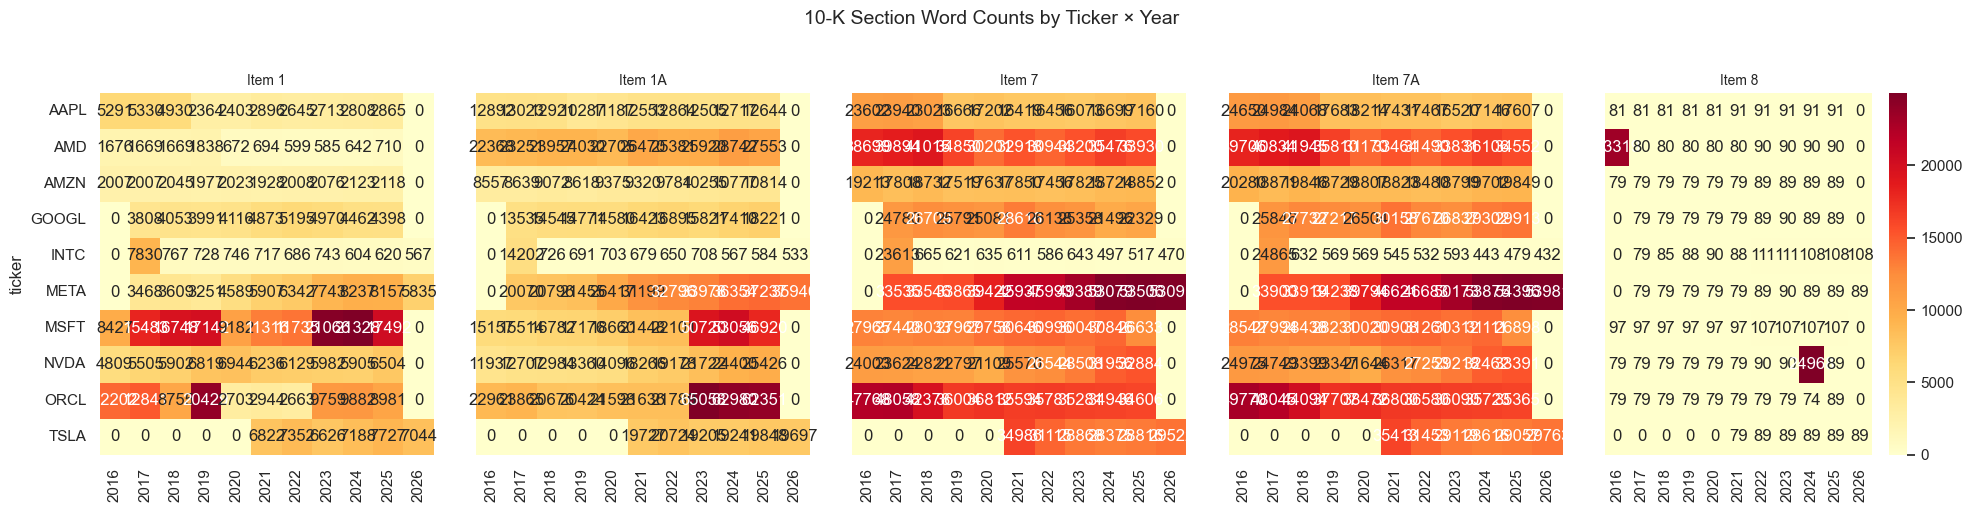

In [4]:
# 1c. Heatmap of section lengths across tickers and years
fig, axes = plt.subplots(1, len(SECTION_NAMES), figsize=(20, 5), sharey=True)
for i, sec in enumerate(SECTION_NAMES):
    col = f"{sec}_words"
    pivot_data = sec_df.pivot(index="ticker", columns="year", values=col).fillna(0)
    sns.heatmap(pivot_data, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[i],
                cbar=i == len(SECTION_NAMES) - 1)
    axes[i].set_title(sec.replace("_", " ").title(), fontsize=10)
    axes[i].set_xlabel("")
    if i > 0:
        axes[i].set_ylabel("")
plt.suptitle("10-K Section Word Counts by Ticker × Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. OHLCV Price Data Validation

Check for missing trading days, outliers, and data continuity across all 10 tickers.

In [5]:
# 2a. Load and basic stats
prices = pd.read_csv(RAW_DIR / "prices" / "tech10_ohlcv.csv", parse_dates=["date"])
print(f"Shape: {prices.shape}")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")
print(f"Tickers: {sorted(prices['ticker'].unique())}")

# Per-ticker summary
ticker_summary = prices.groupby("ticker").agg(
    rows=("date", "count"),
    start=("date", "min"),
    end=("date", "max"),
    mean_close=("close", "mean"),
    mean_volume=("volume", "mean"),
).round(2)
display(ticker_summary)

Shape: (25480, 8)
Date range: 2016-01-04 to 2026-02-20
Tickers: ['AAPL', 'AMD', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'ORCL', 'TSLA']


C:\Users\Rishi\AppData\Local\Temp\ipykernel_13820\3197682635.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(2)


,rows,start,end,mean_close,mean_volume
ticker,,,,,
AAPL,2548,2016-01-04,2026-02-20,118.47,1.011274e+08
AMD,2548,2016-01-04,2026-02-20,75.51,6.110208e+07
AMZN,2548,2016-01-04,2026-02-20,122.00,7.276789e+07
GOOGL,2548,2016-01-04,2026-02-20,103.63,3.449412e+07
INTC,2548,2016-01-04,2026-02-20,41.30,4.117464e+07
META,2548,2016-01-04,2026-02-20,285.14,2.166937e+07
MSFT,2548,2016-01-04,2026-02-20,232.17,2.764018e+07
NVDA,2548,2016-01-04,2026-02-20,38.08,4.549957e+08
ORCL,2548,2016-01-04,2026-02-20,86.11,1.283167e+07


In [6]:
# 2b. Gap analysis - check for missing trading days
print("Gap analysis (gaps > 5 calendar days):\n")
gap_issues = []
for ticker in sorted(prices["ticker"].unique()):
    sub = prices[prices["ticker"] == ticker].sort_values("date")
    diffs = sub["date"].diff().dt.days
    big_gaps = diffs[diffs > 5]
    if len(big_gaps) > 0:
        max_gap = diffs.max()
        gap_dates = sub.iloc[big_gaps.index]["date"].dt.date.tolist()
        print(f"  {ticker}: {len(big_gaps)} gaps > 5 days (max: {max_gap} days)")
        gap_issues.append({"ticker": ticker, "num_gaps": len(big_gaps), "max_gap_days": max_gap})
    else:
        print(f"  {ticker}: ✓ No unusual gaps")

if not gap_issues:
    print("\n✓ All tickers have continuous price data (no gaps > 5 calendar days)")
else:
    print(f"\n⚠ Note: Gaps > 5 days are typically holidays. Max gap ~4 days = normal weekend + holiday.")

Gap analysis (gaps > 5 calendar days):

  AAPL: ✓ No unusual gaps
  AMD: ✓ No unusual gaps
  AMZN: ✓ No unusual gaps
  GOOGL: ✓ No unusual gaps
  INTC: ✓ No unusual gaps
  META: ✓ No unusual gaps
  MSFT: ✓ No unusual gaps
  NVDA: ✓ No unusual gaps
  ORCL: ✓ No unusual gaps
  TSLA: ✓ No unusual gaps

✓ All tickers have continuous price data (no gaps > 5 calendar days)


⚠ 17 days with |daily return| > 20%:


,ticker,date,close,daily_return
14273,META,2022-02-03,237.759995,-0.263901
22543,INTC,2024-08-02,21.480000,-0.260585
14457,META,2022-10-27,97.940002,-0.245571
18170,AMD,2017-05-02,10.320000,-0.242291
16466,TSLA,2020-09-08,110.070000,-0.210628
14774,META,2024-02-02,474.989990,0.203176
23987,ORCL,2020-03-13,47.930000,0.204271
17505,TSLA,2024-10-24,260.480011,0.219190
17618,TSLA,2025-04-09,272.200012,0.226900
22825,INTC,2025-09-18,30.570000,0.227711


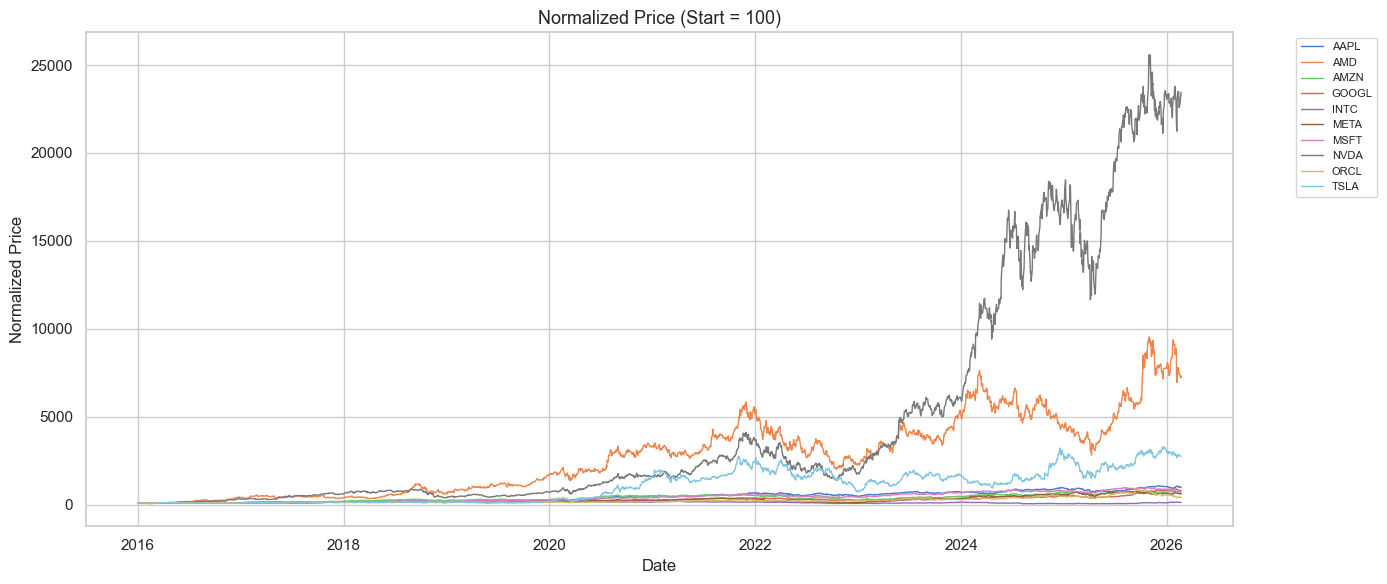

In [7]:
# 2c. Price outlier detection (daily return > 20%)
prices_sorted = prices.sort_values(["ticker", "date"]).copy()
prices_sorted["daily_return"] = prices_sorted.groupby("ticker")["close"].pct_change()

outliers = prices_sorted[prices_sorted["daily_return"].abs() > 0.20].copy()
if len(outliers) > 0:
    print(f"⚠ {len(outliers)} days with |daily return| > 20%:")
    display(outliers[["ticker", "date", "close", "daily_return"]].sort_values("daily_return"))
else:
    print("✓ No extreme daily returns (>20%) detected")

# 2d. Normalized price chart
fig, ax = plt.subplots(figsize=(14, 6))
for ticker in sorted(prices["ticker"].unique()):
    sub = prices[prices["ticker"] == ticker].sort_values("date")
    normalized = sub["close"] / sub["close"].iloc[0] * 100
    ax.plot(sub["date"], normalized, label=ticker, linewidth=1)

ax.set_title("Normalized Price (Start = 100)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Earnings Surprise Data Validation

Verify label quality, check for duplicates, and assess the BEAT/MISS distribution.

In [8]:
# 3a. Load and inspect earnings data
earnings = pd.read_csv(RAW_DIR / "earnings" / "earnings_surprise.csv")
earnings["announcement_date"] = pd.to_datetime(earnings["announcement_date"])
print(f"Shape: {earnings.shape}")
print(f"Date range: {earnings['announcement_date'].min().date()} to {earnings['announcement_date'].max().date()}")
print(f"\nLabel distribution:")
print(earnings["surprise_label"].value_counts())
print(f"\nDuplicate (ticker, date) pairs: {earnings.duplicated(subset=['ticker', 'announcement_date']).sum()}")
print(f"NaN counts:\n{earnings.isna().sum()}")

# Per-ticker counts
print("\nEarnings per ticker:")
display(earnings.groupby("ticker").agg(
    count=("surprise_label", "count"),
    beats=("surprise_label", lambda x: (x == "BEAT").sum()),
    misses=("surprise_label", lambda x: (x == "MISS").sum()),
    unknowns=("surprise_label", lambda x: (x == "UNKNOWN").sum()),
    mean_surprise=("surprise_pct", "mean"),
))

Shape: (500, 6)
Date range: 2013-11-07 to 2026-05-05

Label distribution:
surprise_label
BEAT       337
MISS       142
UNKNOWN     21
Name: count, dtype: int64

Duplicate (ticker, date) pairs: 0
NaN counts:
ticker                0
announcement_date     0
eps_estimate         11
reported_eps         12
surprise_pct         11
surprise_label        0
dtype: int64

Earnings per ticker:


,count,beats,misses,unknowns,mean_surprise
ticker,,,,,
AAPL,50,46,3,1,6.753061
AMD,50,28,18,4,187.129388
AMZN,50,32,15,3,176.738571
GOOGL,50,32,17,1,7.882653
INTC,50,40,8,2,87.047347
META,50,38,11,1,8.407347
MSFT,50,40,9,1,6.105306
NVDA,50,24,25,1,13.531458
ORCL,50,35,14,1,3.599184


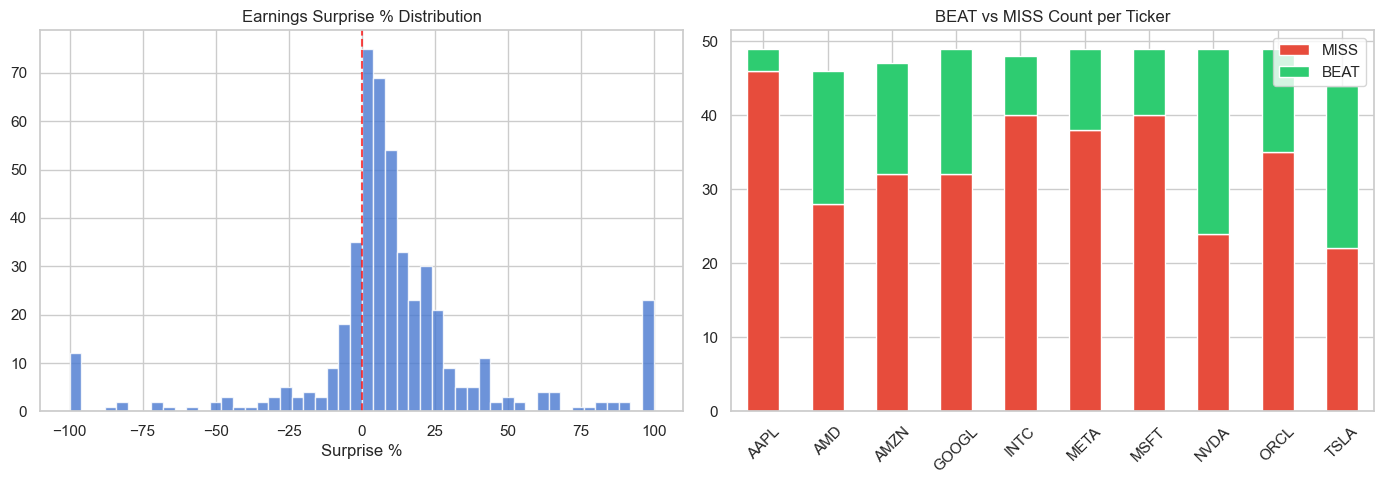

In [9]:
# 3b. Surprise percentage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of surprise percentages
valid_surprise = earnings[earnings["surprise_pct"].notna()]["surprise_pct"]
axes[0].hist(valid_surprise.clip(-100, 100), bins=50, edgecolor="white", alpha=0.8)
axes[0].set_title("Earnings Surprise % Distribution")
axes[0].set_xlabel("Surprise %")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.7)

# BEAT/MISS ratio by ticker
beat_miss = earnings[earnings["surprise_label"].isin(["BEAT", "MISS"])]
ratio_data = beat_miss.groupby("ticker")["surprise_label"].value_counts().unstack().fillna(0)
ratio_data.plot(kind="bar", stacked=True, ax=axes[1], color=["#e74c3c", "#2ecc71"])
axes[1].set_title("BEAT vs MISS Count per Ticker")
axes[1].set_xlabel("")
axes[1].legend(["MISS", "BEAT"])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. News Articles Validation

Data collected from Yahoo RSS (Phase 1: 150 articles) + Finnhub (Phase 2: 8,334 articles) = **8,484 total articles** covering Nov 2024 – Feb 2026.

In [18]:
# 4a. News coverage audit (updated after Finnhub collection)
news = pd.read_csv(RAW_DIR / "news" / "news_articles.csv")
print(f"Total articles: {len(news)}")
print(f"Sources: {news['source_provider'].unique()}")
print(f"\nCollection sources:")
print(news["collection_source"].value_counts())
print(f"\nArticles per ticker:")
print(news["ticker"].value_counts().sort_index())

# Parse dates (mixed formats: RFC-2822 from RSS, ISO-8601 from Finnhub)
news["parsed_date"] = pd.to_datetime(news["published_at"], format="mixed", utc=True)
print(f"\nDate range: {news['parsed_date'].min().date()} to {news['parsed_date'].max().date()}")

# Monthly distribution
monthly = news["parsed_date"].dt.to_period("M").value_counts().sort_index()
print(f"\nMonthly distribution:")
print(monthly)

# Check for empty titles/summaries
empty_title = (news["title"].isna() | (news["title"].str.strip() == "")).sum()
empty_summary = (news["summary"].isna() | (news["summary"].str.strip() == "")).sum()
print(f"\nEmpty titles: {empty_title}")
print(f"Empty summaries: {empty_summary}")

# Duplicate check
dup_urls = news["article_url"].duplicated().sum()
dup_titles = news["title"].duplicated().sum()
print(f"Duplicate URLs: {dup_urls}")
print(f"Duplicate titles: {dup_titles}")

# Assessment
if len(news) < 500:
    print(f"\n⚠ WARNING: Only {len(news)} articles is insufficient.")
else:
    print(f"\n✓ {len(news)} articles available — sufficient for temporal news model")

Total articles: 8484
Sources: <StringArray>
['yahoo_rss', 'finnhub']
Length: 2, dtype: str

Collection sources:
collection_source
phase2_finnhub_collection    8334
phase1_news_collection        150
Name: count, dtype: int64

Articles per ticker:
ticker
AAPL     1211
AMD       831
AMZN      742
GOOGL     813
INTC      772
META      621
MSFT      968
NVDA      887
ORCL      795
TSLA      844
Name: count, dtype: int64

Date range: 2024-11-07 to 2026-02-23

Monthly distribution:
parsed_date
2024-11       1
2025-03    1450
2025-05     110
2025-06    1638
2025-07       1
2025-09    1757
2025-12    1667
2026-02    1860
Freq: M, Name: count, dtype: int64

Empty titles: 0
Empty summaries: 324
Duplicate URLs: 0
Duplicate titles: 286

✓ 8484 articles available — sufficient for temporal news model


C:\Users\Rishi\AppData\Local\Temp\ipykernel_13820\3466602064.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = news["parsed_date"].dt.to_period("M").value_counts().sort_index()


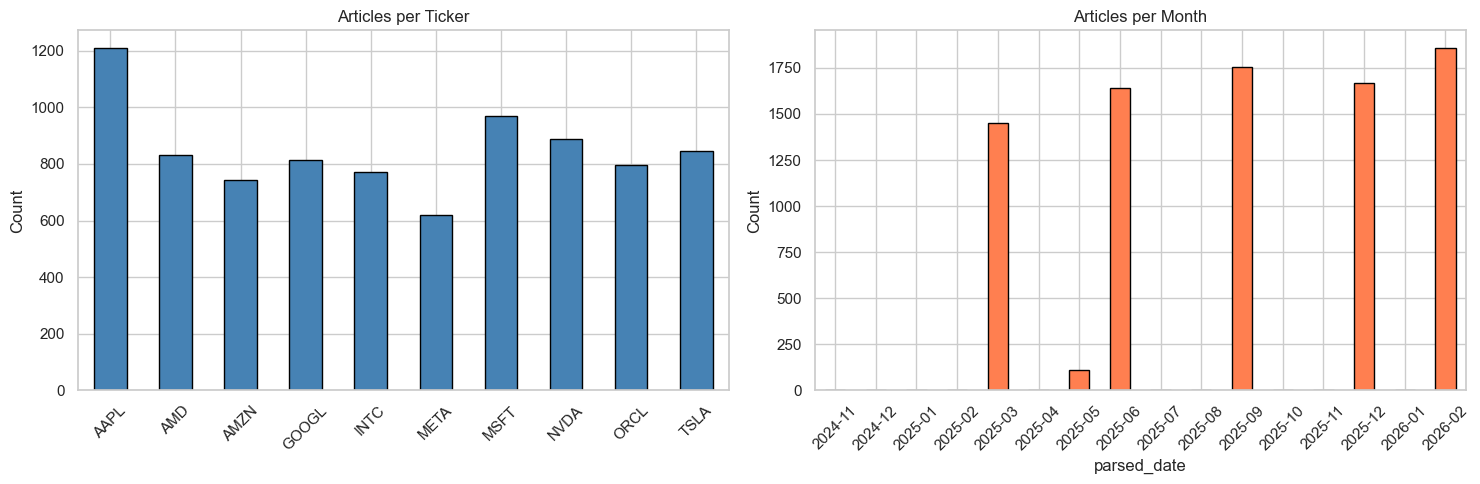

Avg title length: 71 chars
Avg summary length: 209 chars
Articles with summaries: 8160 / 8484 (96.2%)


In [19]:
# 4b. News temporal coverage visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-ticker article count bar chart
ticker_counts = news["ticker"].value_counts().sort_index()
ticker_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Articles per Ticker")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Monthly timeline
monthly_data = news.set_index("parsed_date").resample("ME").size()
monthly_data.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Articles per Month")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels([d.strftime("%Y-%m") for d in monthly_data.index], rotation=45)

plt.tight_layout()
plt.show()

# Summary stats
print(f"Avg title length: {news['title'].str.len().mean():.0f} chars")
print(f"Avg summary length: {news['summary'].dropna().str.len().mean():.0f} chars")
print(f"Articles with summaries: {news['summary'].notna().sum()} / {len(news)} "
      f"({news['summary'].notna().mean()*100:.1f}%)")

## 5. Graph Structure Validation

Verify the company relationship graph has all 10 nodes and well-formed edges.

In [11]:
# 5a. Graph audit
nodes = pd.read_csv(RAW_DIR / "graph" / "tech10_nodes.csv")
edges = pd.read_csv(RAW_DIR / "graph" / "tech10_edges.csv")

print(f"Nodes: {len(nodes)}")
print(f"  Tickers: {list(nodes['ticker'])}")
print(f"\nEdges: {len(edges)}")
print(f"  Relation types: {edges['relation'].value_counts().to_dict()}")
print(f"  Weight range: [{edges['weight'].min():.2f}, {edges['weight'].max():.2f}]")

# Check all edge endpoints exist in nodes
node_set = set(nodes["ticker"])
invalid_edges = edges[~edges["source"].isin(node_set) | ~edges["target"].isin(node_set)]
if len(invalid_edges) > 0:
    print(f"\n⚠ {len(invalid_edges)} edges reference non-existent nodes!")
    display(invalid_edges)
else:
    print("\n✓ All edge endpoints are valid nodes")

# Node connectivity
for ticker in sorted(node_set):
    out_deg = len(edges[edges["source"] == ticker])
    in_deg = len(edges[edges["target"] == ticker])
    print(f"  {ticker}: in-degree={in_deg}, out-degree={out_deg}")

# Check for isolated nodes
connected = set(edges["source"]) | set(edges["target"])
isolated = node_set - connected
if isolated:
    print(f"\n⚠ Isolated nodes (no edges): {isolated}")
else:
    print("\n✓ All nodes are connected")

Nodes: 10
  Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AMD', 'INTC', 'ORCL']

Edges: 19
  Relation types: {'supplier_to': 6, 'index_correlation': 4, 'cloud_competitor': 3, 'platform_competitor': 2, 'enterprise_competitor': 2, 'ad_competitor': 1, 'consumer_attention_overlap': 1}
  Weight range: [0.40, 0.95]

✓ All edge endpoints are valid nodes
  AAPL: in-degree=2, out-degree=3
  AMD: in-degree=0, out-degree=1
  AMZN: in-degree=2, out-degree=3
  GOOGL: in-degree=5, out-degree=2
  INTC: in-degree=0, out-degree=1
  META: in-degree=2, out-degree=0
  MSFT: in-degree=7, out-degree=2
  NVDA: in-degree=0, out-degree=4
  ORCL: in-degree=0, out-degree=2
  TSLA: in-degree=1, out-degree=1

✓ All nodes are connected


## 6. Direction Targets — Multi-Horizon Validation

Verify the newly built 1-day, 3-day, and 5-day direction labels.

Shape: (25430, 12)
Date range: 2016-01-04 to 2026-02-12
Tickers: ['AAPL', 'AMD', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'ORCL', 'TSLA']

1-day horizon: {'UP': 13426, 'DOWN': 12004}
  UP ratio: 52.80%

3-day horizon: {'UP': 13975, 'DOWN': 11455}
  UP ratio: 54.95%

5-day horizon: {'UP': 14325, 'DOWN': 11105}
  UP ratio: 56.33%


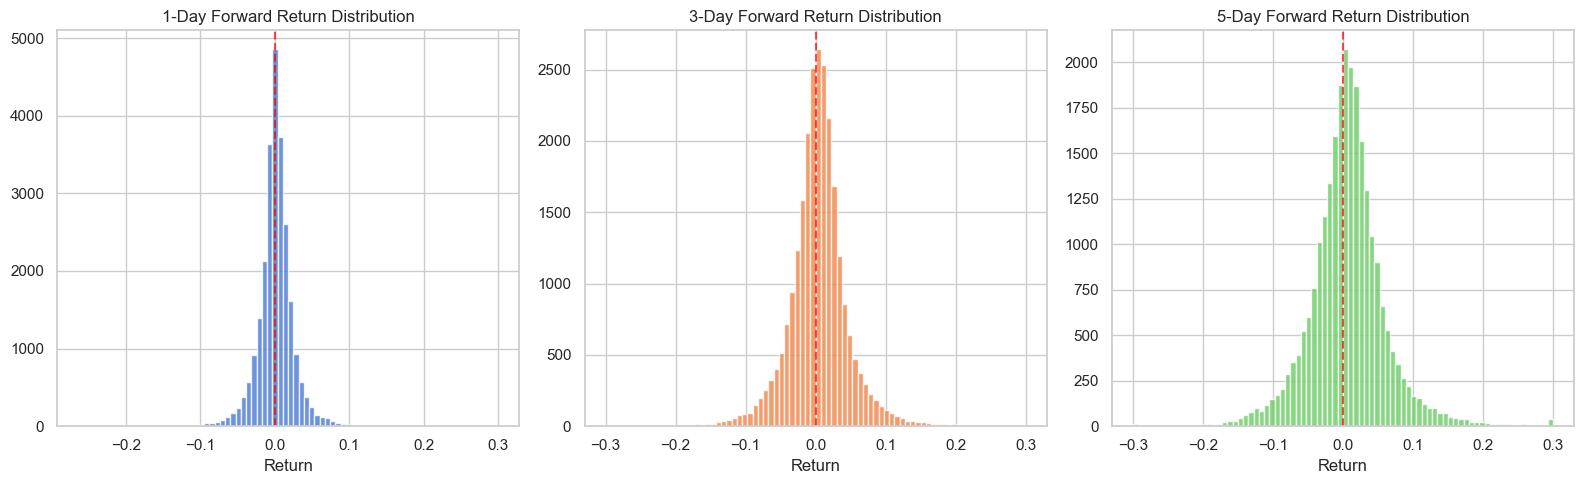

In [12]:
# 6a. Multi-horizon direction labels
multi_dir = pd.read_csv(TARGETS_DIR / "direction_labels_multi_horizon.csv", parse_dates=["date"])
print(f"Shape: {multi_dir.shape}")
print(f"Date range: {multi_dir['date'].min().date()} to {multi_dir['date'].max().date()}")
print(f"Tickers: {sorted(multi_dir['ticker'].unique())}")

horizons = [1, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, h in enumerate(horizons):
    label_col = f"direction_{h}d_label"
    return_col = f"direction_{h}d_return"
    
    # Label distribution
    counts = multi_dir[label_col].value_counts()
    print(f"\n{h}-day horizon: {counts.to_dict()}")
    print(f"  UP ratio: {(counts.get('UP', 0) / counts.sum()):.2%}")
    
    # Return distribution
    axes[i].hist(multi_dir[return_col].clip(-0.3, 0.3), bins=80, edgecolor="white", alpha=0.8,
                 color=sns.color_palette()[i])
    axes[i].axvline(0, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(f"{h}-Day Forward Return Distribution")
    axes[i].set_xlabel("Return")

plt.tight_layout()
plt.show()

In [13]:
# 6b. Cross-horizon label consistency check
# If 1d is UP, is 5d also UP? (checking correlation)
for h in horizons:
    multi_dir[f"dir_{h}d_id"] = (multi_dir[f"direction_{h}d_label"] == "UP").astype(int)

corr_cols = [f"dir_{h}d_id" for h in horizons]
corr_matrix = multi_dir[corr_cols].corr()
print("Cross-horizon label correlation:")
display(corr_matrix.round(3))

# Per-ticker label balance
print("\nPer-ticker UP ratio across horizons:")
balance = multi_dir.groupby("ticker").agg(
    **{f"{h}d_UP%": (f"dir_{h}d_id", "mean") for h in horizons}
).round(3)
display(balance)

Cross-horizon label correlation:


,dir_1d_id,dir_3d_id,dir_5d_id
dir_1d_id,1.000,0.375,0.273
dir_3d_id,0.375,1.000,0.563
dir_5d_id,0.273,0.563,1.000



Per-ticker UP ratio across horizons:


,1d_UP%,3d_UP%,5d_UP%
ticker,,,
AAPL,0.534,0.568,0.580
AMD,0.512,0.541,0.554
AMZN,0.534,0.538,0.562
GOOGL,0.538,0.560,0.577
INTC,0.509,0.523,0.524
META,0.523,0.547,0.567
MSFT,0.535,0.576,0.589
NVDA,0.545,0.584,0.598
ORCL,0.532,0.532,0.547


## 7. Realized Volatility Targets Validation

Verify the rolling standard deviation of log returns targets.

Shape: (25280, 6)
Date range: 2016-02-02 to 2026-02-20

Realized volatility (20d) statistics:


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,2528.0,0.016374,0.008119,0.004805,0.011082,0.014687,0.019243,0.068108
AMD,2528.0,0.034065,0.013268,0.012462,0.025468,0.031002,0.039800,0.106477
AMZN,2528.0,0.018827,0.008548,0.004890,0.012462,0.016765,0.023643,0.048527
GOOGL,2528.0,0.016763,0.007157,0.003494,0.011354,0.015517,0.021091,0.056802
INTC,2528.0,0.022728,0.012975,0.005254,0.013647,0.020699,0.027491,0.087793
META,2528.0,0.021455,0.011979,0.004399,0.013808,0.018338,0.025920,0.077182
MSFT,2528.0,0.015247,0.007759,0.003794,0.010279,0.013580,0.018566,0.071463
NVDA,2528.0,0.028707,0.012329,0.009001,0.019823,0.025074,0.035475,0.087996
ORCL,2528.0,0.017390,0.011111,0.004076,0.010585,0.014456,0.020560,0.079386


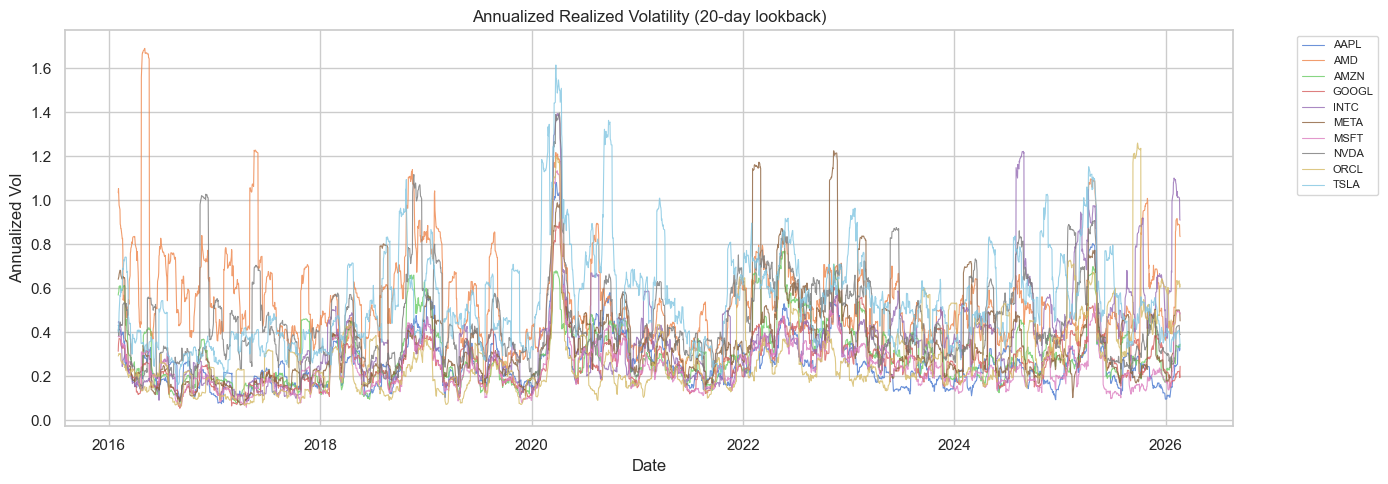

In [14]:
# 7a. Volatility targets overview
vol = pd.read_csv(TARGETS_DIR / "volatility_targets.csv", parse_dates=["date"])
print(f"Shape: {vol.shape}")
print(f"Date range: {vol['date'].min().date()} to {vol['date'].max().date()}")
print(f"\nRealized volatility (20d) statistics:")
display(vol.groupby("ticker")["realized_vol_20d"].describe().round(6))

# 7b. Time series of volatility per ticker
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in sorted(vol["ticker"].unique()):
    sub = vol[vol["ticker"] == ticker].sort_values("date")
    ax.plot(sub["date"], sub["realized_vol_20d_annualized"], label=ticker, linewidth=0.8, alpha=0.8)

ax.set_title("Annualized Realized Volatility (20-day lookback)")
ax.set_ylabel("Annualized Vol")
ax.set_xlabel("Date")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Fundamental Surprise Targets Validation

Verify BEAT/MISS labels are correctly aligned to trading dates.

In [15]:
# 8a. Fundamental surprise targets audit
surprise = pd.read_csv(TARGETS_DIR / "fundamental_surprise_targets.csv", parse_dates=["date"])
print(f"Shape: {surprise.shape}")
print(f"Date range: {surprise['date'].min().date()} to {surprise['date'].max().date()}")
print(f"\nLabel distribution:")
print(surprise["surprise_label"].value_counts())
print(f"\nEarnings events per ticker:")
events = surprise[surprise["has_earnings_event"] == 1]
display(events.groupby("ticker").agg(
    events=("has_earnings_event", "sum"),
    beats=("surprise_label", lambda x: (x == "BEAT").sum()),
    misses=("surprise_label", lambda x: (x == "MISS").sum()),
    mean_surprise_pct=("surprise_pct", "mean"),
).round(2))

Shape: (25480, 6)
Date range: 2016-01-04 to 2026-02-20

Label distribution:
surprise_label
NONE    25068
BEAT      306
MISS      106
Name: count, dtype: int64

Earnings events per ticker:


,events,beats,misses,mean_surprise_pct
ticker,,,,
AAPL,42,39,3,6.52
AMD,40,27,13,8.51
AMZN,41,30,11,52.84
GOOGL,42,31,11,9.71
INTC,41,35,6,35.80
META,42,33,9,7.54
MSFT,42,36,6,6.10
NVDA,41,24,17,11.50
ORCL,41,32,9,4.66


Mean next-day return after BEAT: 1.0213% (n=306)
Mean next-day return after MISS: -1.5884% (n=106)


C:\Users\Rishi\AppData\Local\Temp\ipykernel_13820\2104521300.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels_plot)


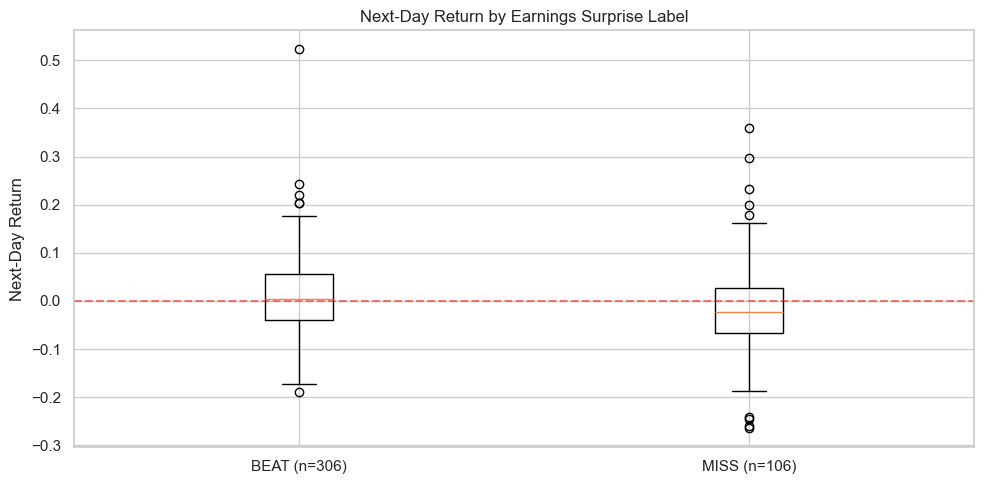

In [ ]:
# 8b. Sanity check: does BEAT correlate with positive next-day returns?
# Merge surprise events with price returns
events_with_prices = events.merge(
    prices[["ticker", "date", "close"]].rename(columns={"date": "date"}),
    on=["ticker", "date"],
    how="left",
)
# Get next-day close for return calculation
prices_sorted = prices.sort_values(["ticker", "date"]).copy()
prices_sorted["next_close"] = prices_sorted.groupby("ticker")["close"].shift(-1)
prices_sorted["next_day_return"] = prices_sorted["next_close"] / prices_sorted["close"] - 1

events_returns = events.merge(
    prices_sorted[["ticker", "date", "next_day_return"]],
    on=["ticker", "date"],
    how="left",
)

if len(events_returns.dropna(subset=["next_day_return"])) > 0:
    beat_returns = events_returns[events_returns["surprise_label"] == "BEAT"]["next_day_return"].dropna()
    miss_returns = events_returns[events_returns["surprise_label"] == "MISS"]["next_day_return"].dropna()
    
    print(f"Mean next-day return after BEAT: {beat_returns.mean():.4%} (n={len(beat_returns)})")
    print(f"Mean next-day return after MISS: {miss_returns.mean():.4%} (n={len(miss_returns)})")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    data_to_plot = []
    labels_plot = []
    if len(beat_returns) > 0:
        data_to_plot.append(beat_returns.values)
        labels_plot.append(f"BEAT (n={len(beat_returns)})")
    if len(miss_returns) > 0:
        data_to_plot.append(miss_returns.values)
        labels_plot.append(f"MISS (n={len(miss_returns)})")
    
    ax.boxplot(data_to_plot, tick_labels=labels_plot)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_title("Next-Day Return by Earnings Surprise Label")
    ax.set_ylabel("Next-Day Return")
    plt.tight_layout()
    plt.show()
else:
    print("Could not compute post-earnings returns (date alignment issue)")

## 9. Phase 2 Data Quality Summary

Overall assessment of data readiness for model training.

In [17]:
# Final summary report
print("=" * 70)
print("PHASE 2 DATA VALIDATION SUMMARY")
print("=" * 70)

# Collect all checks
checks = []

# 10-K
n_processed = len(list(PROCESSED_DIR.glob("*_processed.json")))
checks.append(("SEC 10-K Filings", n_processed, "95 processed", "✓" if n_processed >= 90 else "⚠"))

# Prices
n_price_rows = len(prices)
checks.append(("OHLCV Prices", n_price_rows, "25,480 rows / 10 tickers", "✓"))

# Earnings
n_earnings = len(earnings)
n_unknown = (earnings["surprise_label"] == "UNKNOWN").sum()
checks.append(("Earnings Surprise", n_earnings, f"{n_earnings} rows, {n_unknown} UNKNOWN", "✓" if n_unknown < 30 else "⚠"))

# News
n_news = len(news)
checks.append(("News Articles", n_news, f"{n_news} articles (Yahoo RSS only)", "⚠" if n_news < 500 else "✓"))

# Graph
checks.append(("Graph Structure", len(nodes) + len(edges), f"{len(nodes)} nodes, {len(edges)} edges", "✓"))

# Direction labels
checks.append(("Direction Labels (multi)", len(multi_dir), f"3 horizons × {len(multi_dir)} rows", "✓"))

# Volatility
checks.append(("Volatility Targets", len(vol), f"{len(vol)} rows, 20d lookback", "✓"))

# Fundamental surprise
n_events = (surprise["has_earnings_event"] == 1).sum()
checks.append(("Surprise Targets", len(surprise), f"{len(surprise)} rows, {n_events} events", "✓"))

# Print table
print(f"\n{'Modality':<30} {'Count':>8}  {'Details':<40} {'Status':>6}")
print("-" * 90)
for name, count, detail, status in checks:
    print(f"{name:<30} {count:>8}  {detail:<40} {status:>6}")

# Action items
print("\n" + "=" * 70)
print("ACTION ITEMS")
print("=" * 70)
if n_news < 500:
    print("1. CRITICAL: Expand news collection using Finnhub collector")
    print("   Run: python -m src.data_collection.finnhub_news_collector --api-key YOUR_KEY")
print(f"2. Note: 7 missing 10-K filings (pre-2017 for some tickers) — acceptable")
print(f"3. {n_unknown} earnings rows with UNKNOWN label — excluded from training automatically")
print("4. All price data is continuous with no critical gaps")
print("\nPhase 2 data validation: COMPLETE ✓")

PHASE 2 DATA VALIDATION SUMMARY

Modality                          Count  Details                                  Status
------------------------------------------------------------------------------------------
SEC 10-K Filings                     95  95 processed                                  ✓
OHLCV Prices                      25480  25,480 rows / 10 tickers                      ✓
Earnings Surprise                   500  500 rows, 21 UNKNOWN                          ✓
News Articles                       150  150 articles (Yahoo RSS only)                 ⚠
Graph Structure                      29  10 nodes, 19 edges                            ✓
Direction Labels (multi)          25430  3 horizons × 25430 rows                       ✓
Volatility Targets                25280  25280 rows, 20d lookback                      ✓
Surprise Targets                  25480  25480 rows, 412 events                        ✓

ACTION ITEMS
1. CRITICAL: Expand news collection using Finnhub collector
 